# DCT1401 - Inteligência Artificial (UFRN)
## Atividade Prática Avaliativa: Análise Exploratória de Dados (EDA)
**Aluno:** Wallison Valdemiro Silvino Dias  
**Matrícula:** 20250023771  
**Dataset:** Greek Urban Air Quality & Health Impact Dataset (2020-2024)  
**Repositório:** [GitHub - air-quality-data](https://github.com/wallisonvsdias/air-quality-data)

---
### Objetivos Desta Etapa
1. Carregamento e inspeção estrutural do dataset bruto (dimensões, tipos de dados, amostras).
2. Cálculo de estatísticas descritivas completas para variáveis numéricas e contagem de frequências para categóricas.
3. Identificação e diagnóstico visual de valores ausentes.
4. Detecção quantitativa e visual de outliers (método IQR e Boxplots).
5. Análise de correlações lineares de Pearson e identificação de multicolinearidade.
6. Visualizações de distribuição, relações bivariadas e dispersão espacial/contextual.

In [1]:
import sys
from pathlib import Path

# Adiciona o diretório raiz ao path para importar o pacote src
root_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src import data_loader, eda, visualization

visualization.set_plot_style()
print("Ambiente configurado com sucesso e módulos de src/ carregados.")

Ambiente configurado com sucesso e módulos de src/ carregados.


### 1. Carregamento e Inspeção Inicial
Carregamos o dataset bruto localizado em `data/raw/greek_urban_air_quality_2020_2024.csv` e verificamos suas dimensões, tipos de dados e primeiros/últimos registros.

In [2]:
# Carregamento do dataset bruto
df = data_loader.load_raw_data()

summary = eda.get_dataset_summary(df)
print(f"Dimensões do Dataset: {summary['n_rows']:,} linhas x {summary['n_cols']} colunas")
print(f"Registros Duplicados: {summary['duplicates']}")
print(f"Total de Variáveis Numéricas: {len(summary['numeric_cols'])}")
print(f"Total de Variáveis Categóricas/Texto: {len(summary['categorical_cols'])}")

print("\n--- Tipos de Dados por Coluna ---")
display(pd.DataFrame({"Tipo de Dado": df.dtypes}))

Dimensões do Dataset: 453,096 linhas x 32 colunas
Registros Duplicados: 0
Total de Variáveis Numéricas: 27
Total de Variáveis Categóricas/Texto: 4

--- Tipos de Dados por Coluna ---


,Tipo de Dado
timestamp,datetime64[us]
city,str
station,str
latitude,float64
longitude,float64
population,int64
industrial_index,float64
PM2_5_ugm3,float64
PM10_ugm3,float64
NO2_ugm3,float64


In [3]:
# Primeiras 5 linhas do dataset
display(df.head())

,timestamp,city,station,latitude,longitude,population,industrial_index,PM2_5_ugm3,PM10_ugm3,NO2_ugm3,...,UV_Index,Traffic_Density_Index,Heating_Season,Saharan_Dust_Event,Wildfire_Smoke_Event,Health_Risk_Children,Health_Risk_Adults,Health_Risk_Elderly,Est_Respiratory_Cases_per_100k,Outdoor_Activity_Recommendation
0,2020-01-01,Athens,Athens_Marousi,38.020730,23.753381,3154000,0.4,14.78,23.97,20.85,...,0.0,33.2,1,0,0,28.41,20.29,32.47,17.12,Sensitive groups limit outdoor activity
1,2020-01-01,Athens,Athens_Piraeus,38.019971,23.735235,3154000,0.4,10.69,15.19,26.75,...,0.0,38.2,1,0,0,24.81,17.72,28.35,12.15,Sensitive groups limit outdoor activity
2,2020-01-01,Athens,Athens_Kifissia,37.987214,23.701981,3154000,0.4,11.64,28.57,37.01,...,0.0,38.4,1,0,0,32.92,23.51,37.62,13.28,Sensitive groups limit outdoor activity
3,2020-01-01,Athens,Athens_Patissia,37.973363,23.768955,3154000,0.4,14.30,16.12,28.31,...,0.0,38.7,1,0,0,30.14,21.53,34.44,15.03,Sensitive groups limit outdoor activity
4,2020-01-01,Athens,Athens_Peristeri,37.993441,23.715977,3154000,0.4,10.53,20.29,36.83,...,0.0,39.1,1,0,0,30.51,21.79,34.87,13.65,Sensitive groups limit outdoor activity


In [4]:
# Últimas 5 linhas do dataset
display(df.tail())

,timestamp,city,station,latitude,longitude,population,industrial_index,PM2_5_ugm3,PM10_ugm3,NO2_ugm3,...,UV_Index,Traffic_Density_Index,Heating_Season,Saharan_Dust_Event,Wildfire_Smoke_Event,Health_Risk_Children,Health_Risk_Adults,Health_Risk_Elderly,Est_Respiratory_Cases_per_100k,Outdoor_Activity_Recommendation
453091,2024-12-31 15:00:00,Alexandroupoli,Alexandroupoli_Port,40.847479,25.869653,72000,0.2,6.72,22.32,9.68,...,0.9,21.8,1,0,0,22.89,16.35,26.16,13.06,All activities safe
453092,2024-12-31 18:00:00,Alexandroupoli,Alexandroupoli_Center,40.835692,25.875041,72000,0.2,21.31,38.99,39.66,...,0.4,24.9,1,0,0,40.27,28.76,46.02,22.17,Reduce prolonged outdoor activity
453093,2024-12-31 18:00:00,Alexandroupoli,Alexandroupoli_Port,40.836364,25.921027,72000,0.2,6.75,20.38,16.27,...,0.0,35.8,1,0,0,21.30,15.22,24.35,12.73,All activities safe
453094,2024-12-31 21:00:00,Alexandroupoli,Alexandroupoli_Center,40.887419,25.895586,72000,0.2,10.43,20.26,25.97,...,0.0,15.1,1,0,0,27.79,19.85,31.76,11.53,Sensitive groups limit outdoor activity
453095,2024-12-31 21:00:00,Alexandroupoli,Alexandroupoli_Port,40.837542,25.870353,72000,0.2,4.11,8.37,15.83,...,0.0,20.9,1,0,0,16.69,11.92,19.07,15.24,All activities safe


### 2. Estatísticas Descritivas
Calculamos as métricas de tendência central, dispersão e separatrizes para as variáveis numéricas, além da distribuição de frequências das variáveis categóricas.

In [5]:
# Resumo estatístico das variáveis numéricas
num_stats = eda.get_numerical_summary(df)
display(num_stats.round(2))

,Contagem,Média,Desvio Padrão,Mínimo,Q1 (25%),Mediana (50%),Q3 (75%),Máximo,IQR
latitude,453096,38.80,1.80,35.29,37.97,39.37,40.60,40.99,2.63
longitude,453096,23.54,1.77,20.80,22.41,22.99,24.37,28.27,1.96
population,453096,756774.19,1100386.09,70000.00,108000.00,167000.00,1110000.00,3154000.00,1002000.00
industrial_index,453096,0.41,0.23,0.10,0.20,0.40,0.60,0.90,0.40
PM2_5_ugm3,453096,17.44,12.96,1.00,8.21,14.75,23.96,166.11,15.75
PM10_ugm3,453096,31.77,24.15,1.00,14.27,26.69,43.65,336.10,29.38
NO2_ugm3,453096,31.44,22.64,2.00,15.59,26.33,41.56,182.81,25.97
O3_ugm3,453096,46.39,11.61,5.00,38.38,45.81,54.17,97.27,15.79
SO2_ugm3,453096,14.62,9.17,0.50,7.50,13.86,20.83,56.47,13.33
CO_mgm3,453096,1.03,0.74,0.10,0.51,0.87,1.38,5.59,0.87


In [6]:
# Frequências das variáveis categóricas
cat_summaries = eda.get_categorical_summary(df)
for col_name, freq_df in cat_summaries.items():
    if col_name != "timestamp":
        print(f"\n=== Frequência da Variável Categórica: {col_name} ===")
        display(freq_df.round(2))


=== Frequência da Variável Categórica: city ===


,Frequência,Percentual (%)
city,,
Athens,73080,16.13
Thessaloniki,58464,12.90
Patras,43848,9.68
Volos,43848,9.68
Heraklion,29232,6.45
Larissa,29232,6.45
Ioannina,29232,6.45
Kavala,29232,6.45
Rhodes,29232,6.45



=== Frequência da Variável Categórica: station ===


,Frequência,Percentual (%)
station,,
Athens_Marousi,14616,3.23
Athens_Piraeus,14616,3.23
Athens_Kifissia,14616,3.23
Athens_Patissia,14616,3.23
Athens_Peristeri,14616,3.23
Thessaloniki_Kalamaria,14616,3.23
Thessaloniki_Panorama,14616,3.23
Thessaloniki_Ampelokipoi,14616,3.23
Thessaloniki_Stavroupoli,14616,3.23



=== Frequência da Variável Categórica: AQI_Category ===


,Frequência,Percentual (%)
AQI_Category,,
Moderate,179602,39.64
Unhealthy for Sensitive Groups,105918,23.38
Good,89142,19.67
Unhealthy,50022,11.04
Very Unhealthy,24662,5.44
Hazardous,3750,0.83



=== Frequência da Variável Categórica: Outdoor_Activity_Recommendation ===


,Frequência,Percentual (%)
Outdoor_Activity_Recommendation,,
Sensitive groups limit outdoor activity,179602,39.64
Reduce prolonged outdoor activity,105918,23.38
All activities safe,89142,19.67
Avoid outdoor activity,78434,17.31


### 3. Identificação e Diagnóstico de Valores Ausentes
Avaliamos a presença de nulos por coluna e geramos o gráfico correspondente salvo em `reports/figures/missing_values.png`.

Total de valores ausentes em todo o dataset: 0


Gráfico salvo em: C:\Users\walli\OneDrive\Documentos\bsi_ofc\4-semestre\ia\air-quality-data\reports\figures\missing_values.png


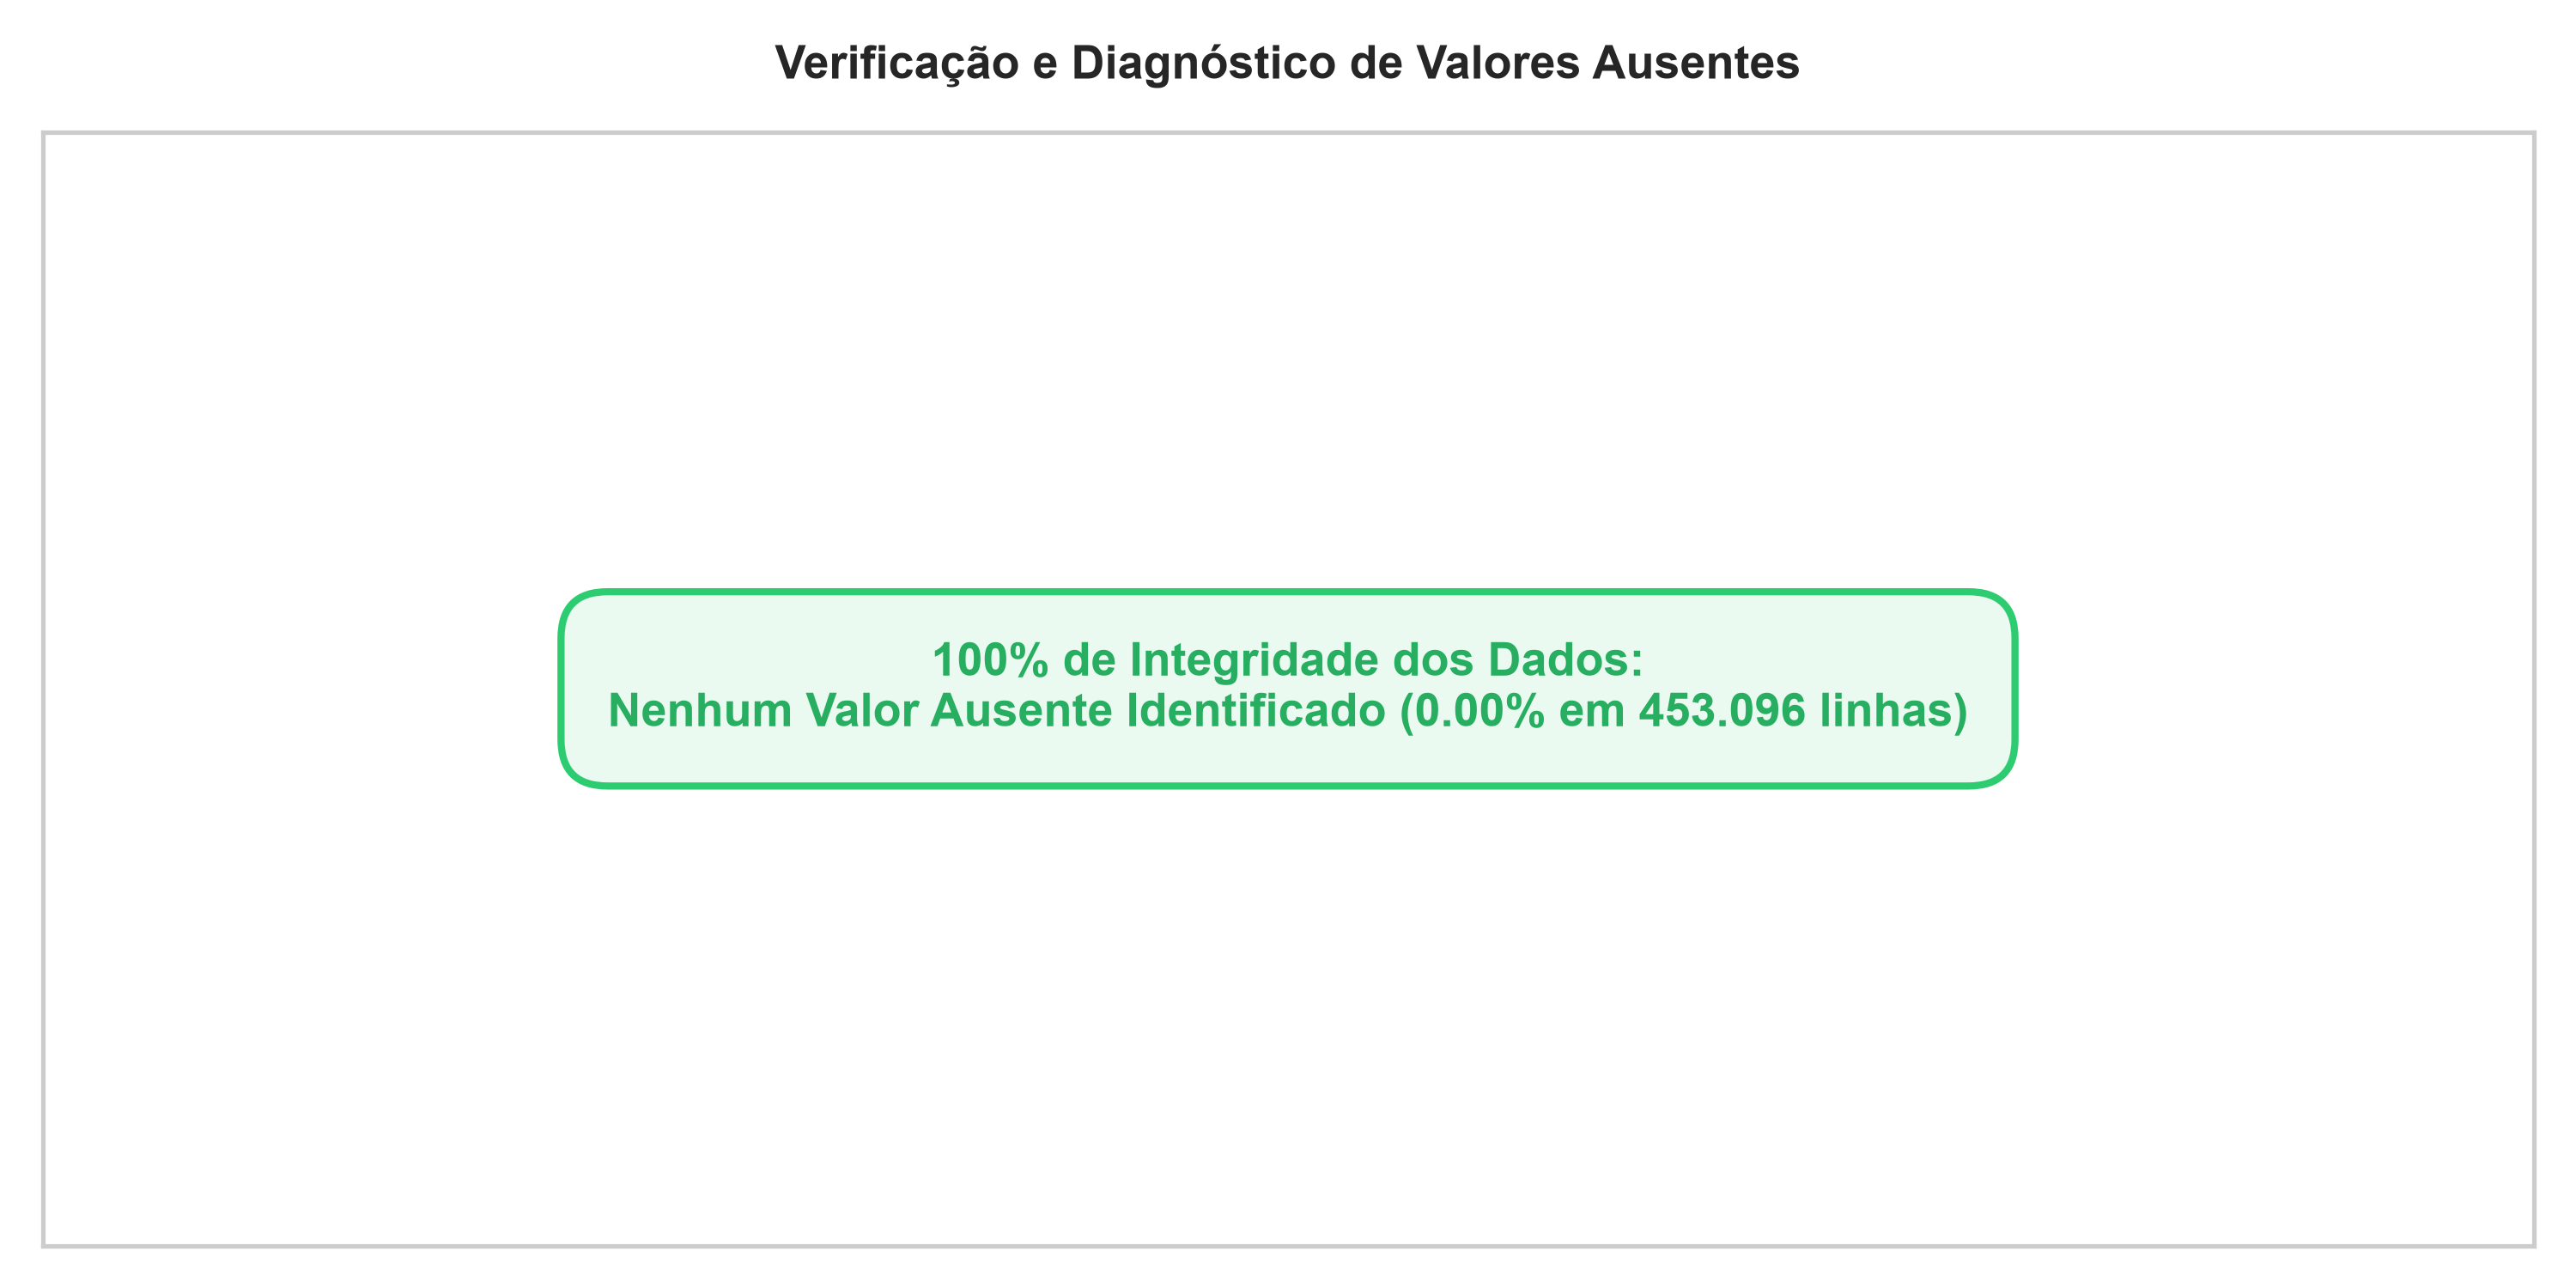

In [7]:
# Cálculo de valores ausentes
missing_total = df.isnull().sum().sum()
print(f"Total de valores ausentes em todo o dataset: {missing_total}")

# Gera e salva a visualização de diagnóstico
fig_missing_path = visualization.plot_missing_values(df, "missing_values.png")
print(f"Gráfico salvo em: {fig_missing_path}")

# Exibe a figura gerada
from IPython.display import Image
Image(filename=str(fig_missing_path))

**Interpretação e Discussão de Valores Ausentes:**
O dataset apresenta **0 valores ausentes** em todas as 453.096 linhas e 32 colunas (100% de preenchimento). Isso reflete a natureza do dataset coletado por redes de telemetria automatizadas com curadoria e pré-validação técnica. O impacto na modelagem futura é altamente positivo, pois elimina a necessidade de descartar registros (*listwise deletion*) ou introduzir ruído por imputação estocástica nos dados brutos. Mantém-se, no entanto, uma rotina de validação defensiva em `src/preprocessing.py` para eventuais lotes novos em produção.

### 4. Detecção de Outliers
Utilizamos o método estatístico do **Intervalo Interquartil (IQR)** de Tukey ($Q_1 - 1.5 \times \text{IQR}$ e $Q_3 + 1.5 \times \text{IQR}$) e análise visual com Boxplots.

In [8]:
# Detecção quantitativa com IQR
outliers_df = eda.detect_outliers_iqr(df)
display(outliers_df.head(15).round(2))

,Variável,Q1,Q3,IQR,Limite Inferior,Limite Superior,Qtd Outliers,Percentual (%)
0,Rainfall_mm,0.00,0.00,0.00,0.00,0.00,90392,19.95
1,population,108000.00,1110000.00,1002000.00,-1395000.00,2613000.00,73080,16.13
2,UV_Index,0.00,2.50,2.50,-3.75,6.25,40439,8.93
3,longitude,22.41,24.37,1.96,19.47,27.31,29232,6.45
4,Traffic_Density_Index,26.90,63.80,36.90,-28.45,119.15,23275,5.14
5,NO2_ugm3,15.59,41.56,25.97,-23.37,80.52,18967,4.19
6,CO_mgm3,0.51,1.38,0.87,-0.79,2.68,17357,3.83
7,Est_Respiratory_Cases_per_100k,13.04,23.75,10.71,-3.03,39.82,16582,3.66
8,Benzene_ugm3,0.62,1.70,1.08,-1.00,3.31,15858,3.50
9,PM10_ugm3,14.27,43.65,29.38,-29.80,87.72,12465,2.75


Boxplot salvo em: C:\Users\walli\OneDrive\Documentos\bsi_ofc\4-semestre\ia\air-quality-data\reports\figures\outliers_boxplot.png


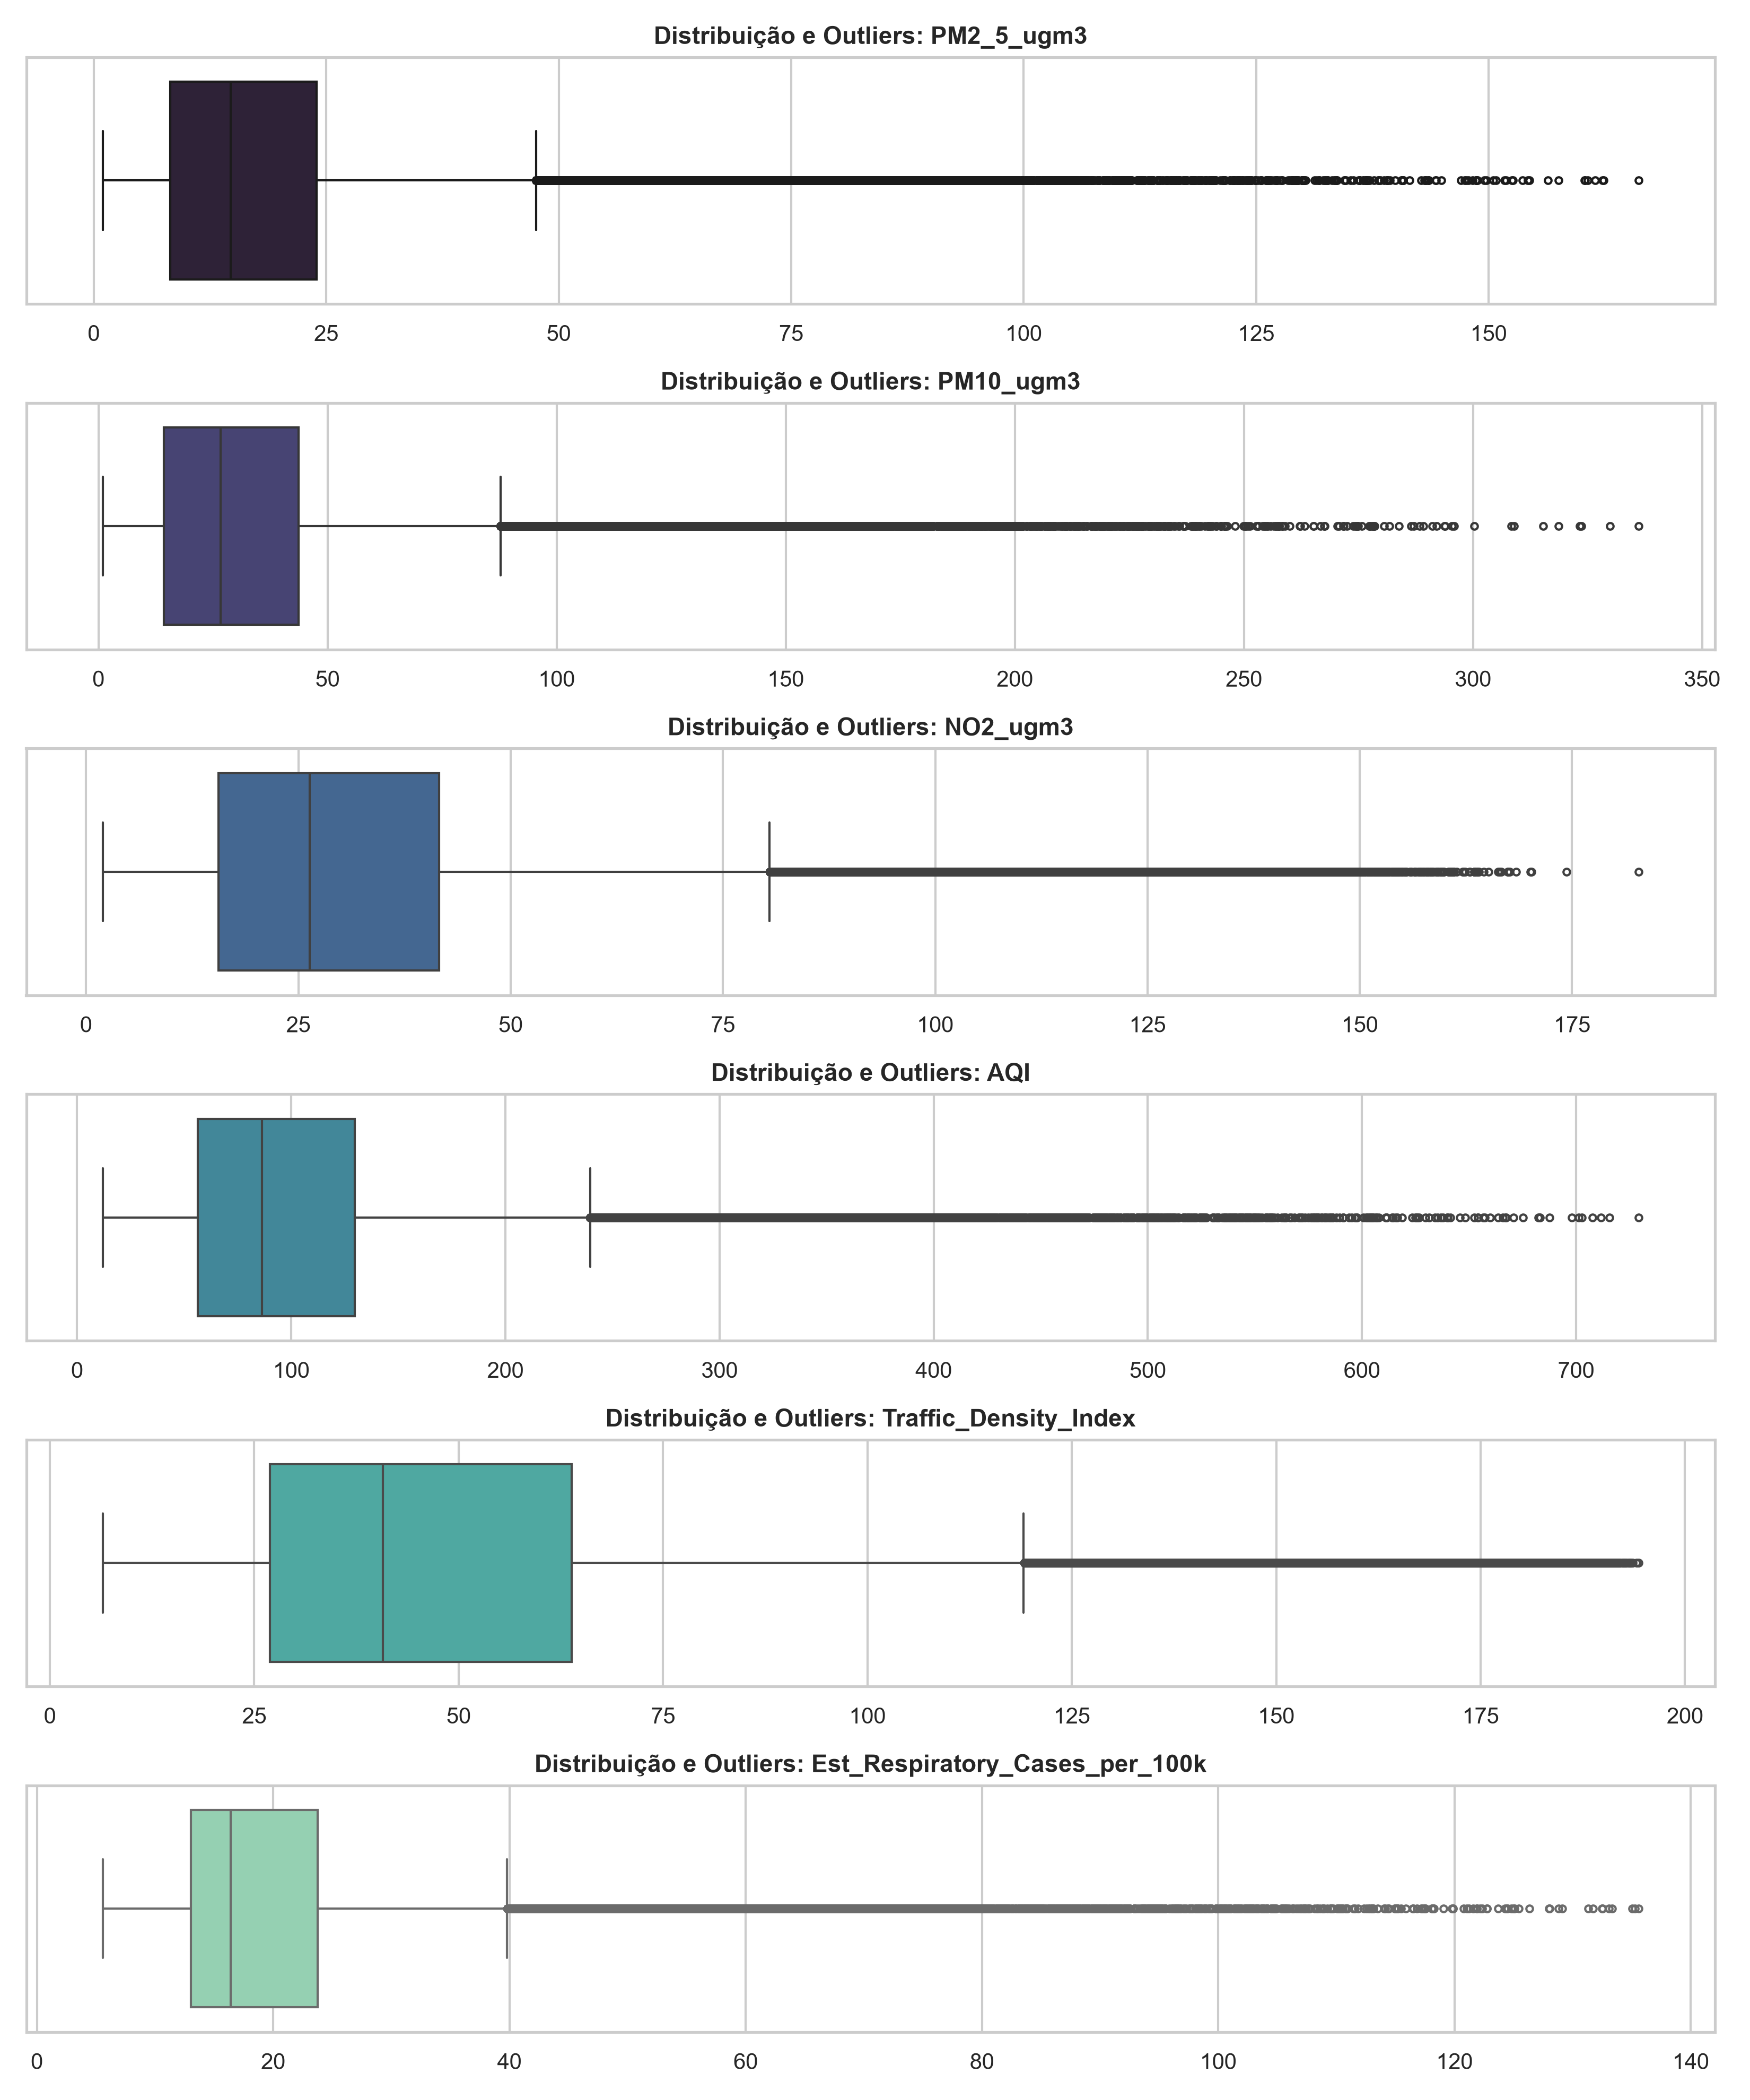

In [9]:
# Visualização gráfica com Boxplots
fig_outliers_path = visualization.plot_outliers_boxplots(df, save_name="outliers_boxplot.png")
print(f"Boxplot salvo em: {fig_outliers_path}")

Image(filename=str(fig_outliers_path))

**Discussão e Origem dos Outliers:**
A detecção estatística apontou concentrações de outliers em variáveis críticas como `Rainfall_mm` (19.95%), `population` (16.13%), `UV_Index` (8.93%), `Traffic_Density_Index` (5.14%), `NO2_ugm3` (4.19%), `CO_mgm3` (3.83%), `PM10_ugm3` (2.75%), `AQI` (2.65%) e `PM2_5_ugm3` (2.61%).

**Origem física e ambiental:**
1. **Eventos Climáticos Naturais Extremos:** Grécia sofre sazonalmente com incêndios florestais no verão (*Wildfire Smoke Events*) e tempestades de poeira desértica vindas do Saara (*Saharan Dust Events*). Esses episódios provocam picos abruptos em $PM_{2.5}$ (>100 $\mu g/m^3$) e $PM_{10}$ (>200 $\mu g/m^3$), que não são falhas de medição, mas sim fenômenos ambientais reais severos.
2. **Dinâmica Urbana e Demografia:** Atenas e Tessalônica concentram populações ordens de magnitude superiores às ilhas e cidades menores (ex: Rodes, Chania), justificando os outliers populacionais e os picos de $NO_2$ e $CO$ gerados por congestionamentos veiculares nos horários de pico.
3. **Pluviometria:** O clima mediterrâneo possui longos períodos sem precipitação (mediana e quartis iguais a 0 mm), fazendo com que qualquer chuva moderada/forte seja categorizada como outlier estatístico.

### 5. Análise de Correlação e Multicolinearidade
Calculamos a matriz de correlação linear de Pearson para todas as variáveis numéricas e inspecionamos os pares com correlações elevadas ($|r| \ge 0.80$).

Heatmap salvo em: C:\Users\walli\OneDrive\Documentos\bsi_ofc\4-semestre\ia\air-quality-data\reports\figures\correlation_matrix.png


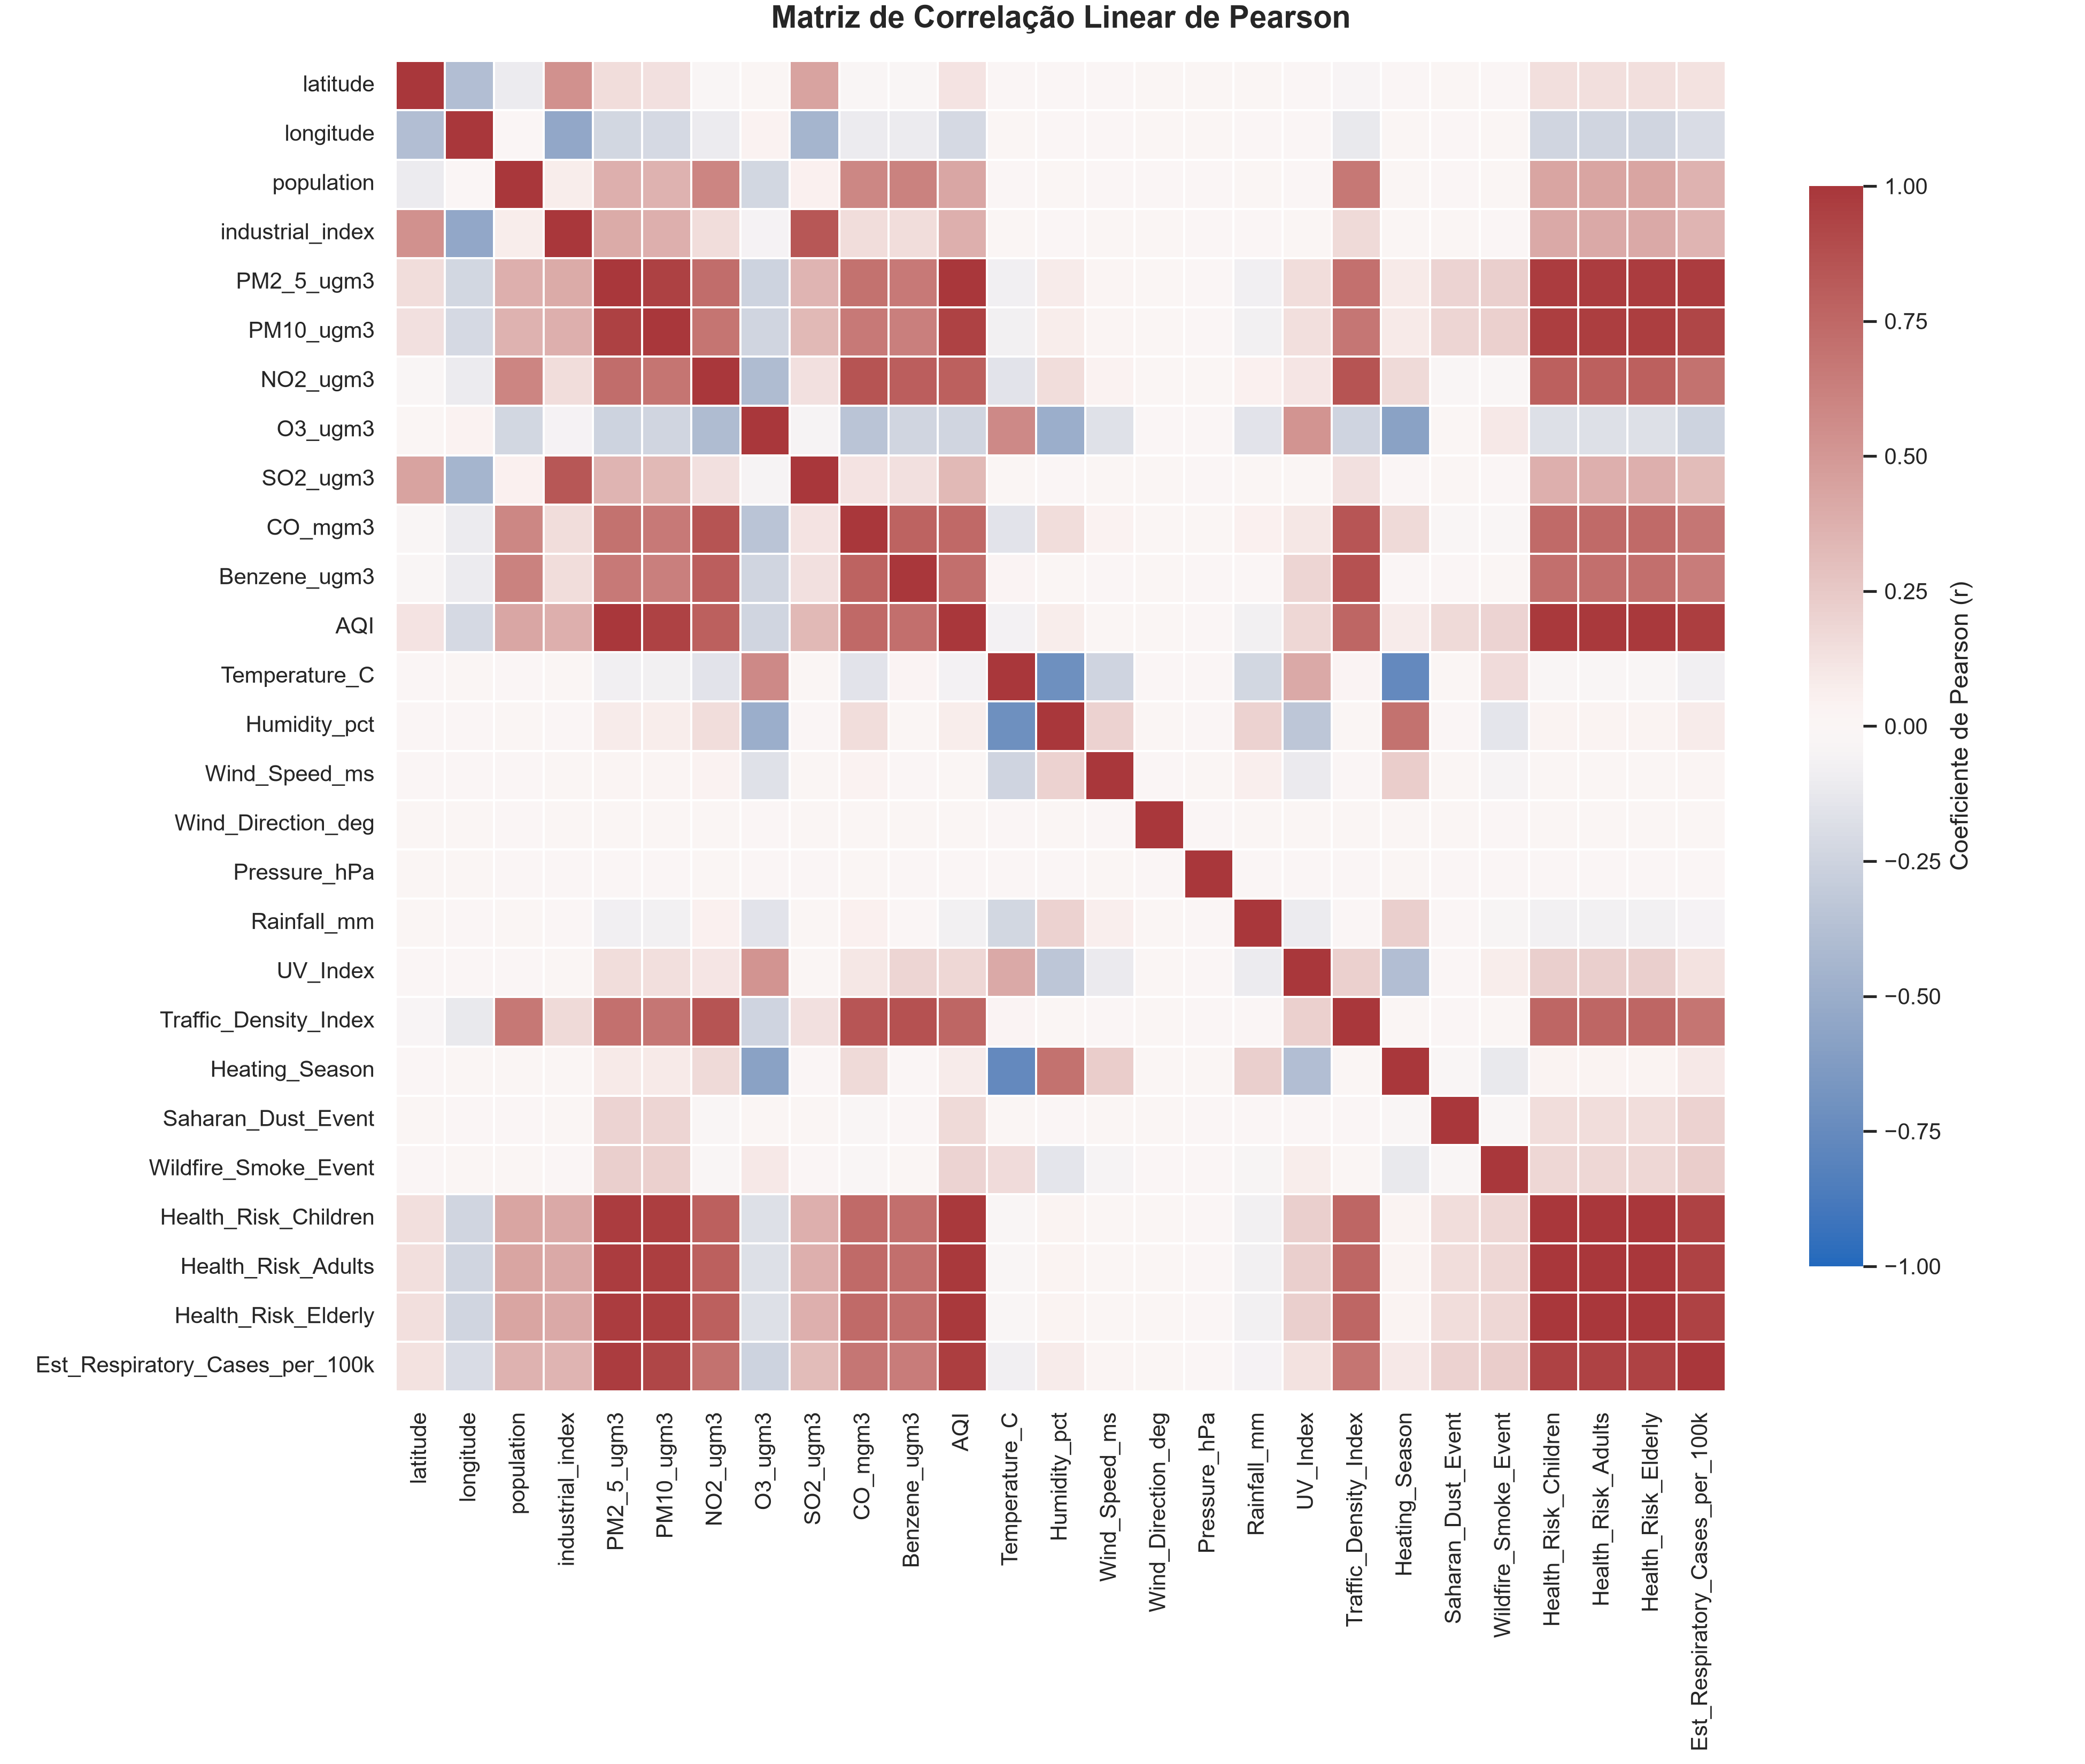

In [10]:
# Cálculo da matriz de correlação
corr_matrix = eda.compute_correlation_matrix(df)

# Mapa de Calor
fig_corr_path = visualization.plot_correlation_heatmap(corr_matrix, "correlation_matrix.png")
print(f"Heatmap salvo em: {fig_corr_path}")

Image(filename=str(fig_corr_path))

In [11]:
# Pares com alta correlação (|r| >= 0.80)
high_corr = eda.find_high_correlations(corr_matrix, threshold=0.80)
high_corr_df = pd.DataFrame(high_corr, columns=["Variável 1", "Variável 2", "Correlação (r)"])
display(high_corr_df.round(4))

,Variável 1,Variável 2,Correlação (r)
0,Health_Risk_Children,Health_Risk_Elderly,1.0000
1,Health_Risk_Adults,Health_Risk_Elderly,1.0000
2,Health_Risk_Children,Health_Risk_Adults,1.0000
3,PM2_5_ugm3,AQI,0.9922
4,AQI,Health_Risk_Elderly,0.9876
5,AQI,Health_Risk_Children,0.9876
6,AQI,Health_Risk_Adults,0.9876
7,PM2_5_ugm3,Health_Risk_Adults,0.9736
8,PM2_5_ugm3,Health_Risk_Children,0.9736
9,PM2_5_ugm3,Health_Risk_Elderly,0.9736


**Discussão sobre Multicolinearidade:**
Foram identificados grupos altamente correlacionados:
- **Índices de Risco em Saúde:** `Health_Risk_Children`, `Health_Risk_Adults` e `Health_Risk_Elderly` possuem correlação mútua exatamente igual a $1.0000$. São transformações escalares determinísticas entre si e devem ser removidas conjuntamente em tarefas preditivas para evitar colinearidade perfeita.
- **Material Particulado e AQI:** $PM_{2.5}$ e $PM_{10}$ possuem $r = 0.951$, e $PM_{2.5}$ com $AQI$ atinge $r = 0.992$. Isso ocorre porque o índice de qualidade do ar oficial adota a concentração de $PM_{2.5}$ como poluente crítico preponderante.
- **Poluentes Veiculares:** $NO_2$, $CO$, Benzzeno e $Traffic\_Density\_Index$ apresentam correlações superiores a $0.85$, refletindo a queima de combustíveis fósseis no tráfego urbano.
- **Implicações para Modelagem:** Para modelos lineares (Regressão Linear, Regressão Logística), essa multicolinearidade causa instabilidade nos coeficientes, inflacionando a variância (*Variance Inflation Factor* - VIF). Recomenda-se regularização ($L_1$ Lasso, $L_2$ Ridge) ou seleção de variáveis (mantendo apenas o preditor principal). Modelos baseados em árvores (Random Forest, XGBoost) são naturalmente mais robustos à colinearidade.

### 6. Visualizações de Dados Detalhadas
Apresentamos gráficos adicionais para investigar distribuições e relações bivariadas.

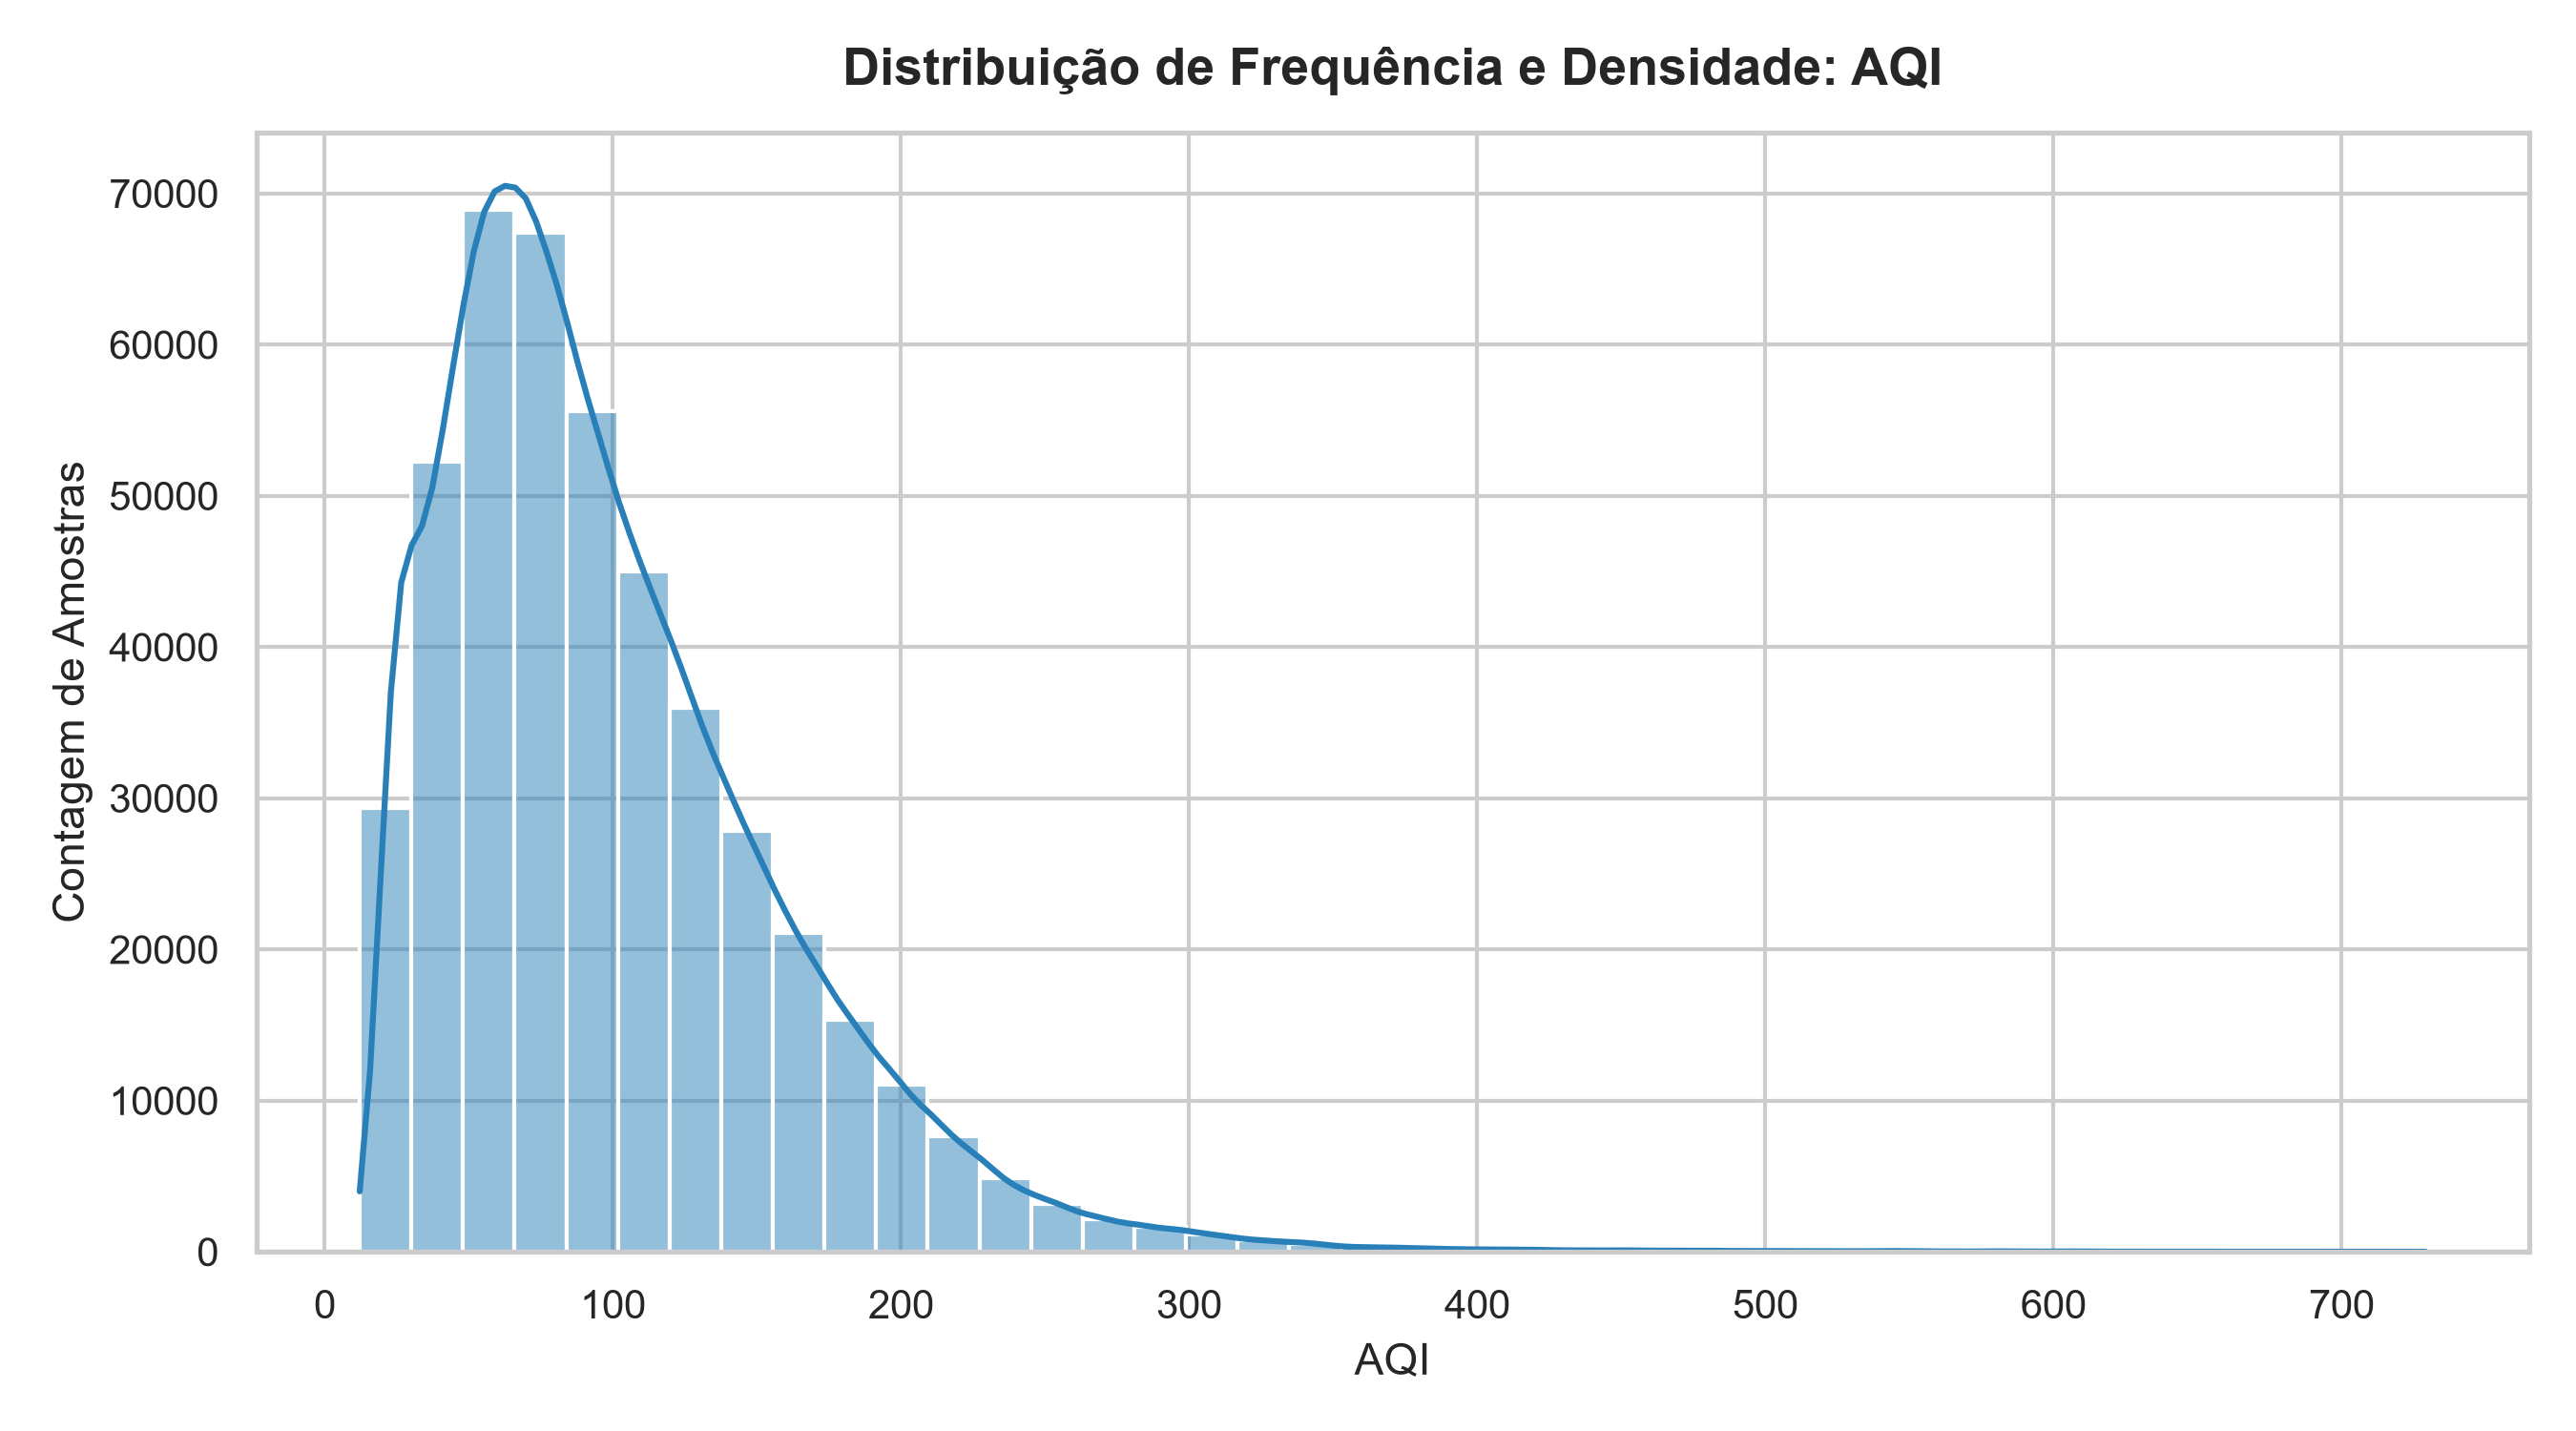

In [12]:
# 1. Distribuição de Frequência do AQI (Target de Regressão)
fig_dist_aqi = visualization.plot_distribution(df, "AQI", "distribution_aqi.png", color="#2980b9")
Image(filename=str(fig_dist_aqi))

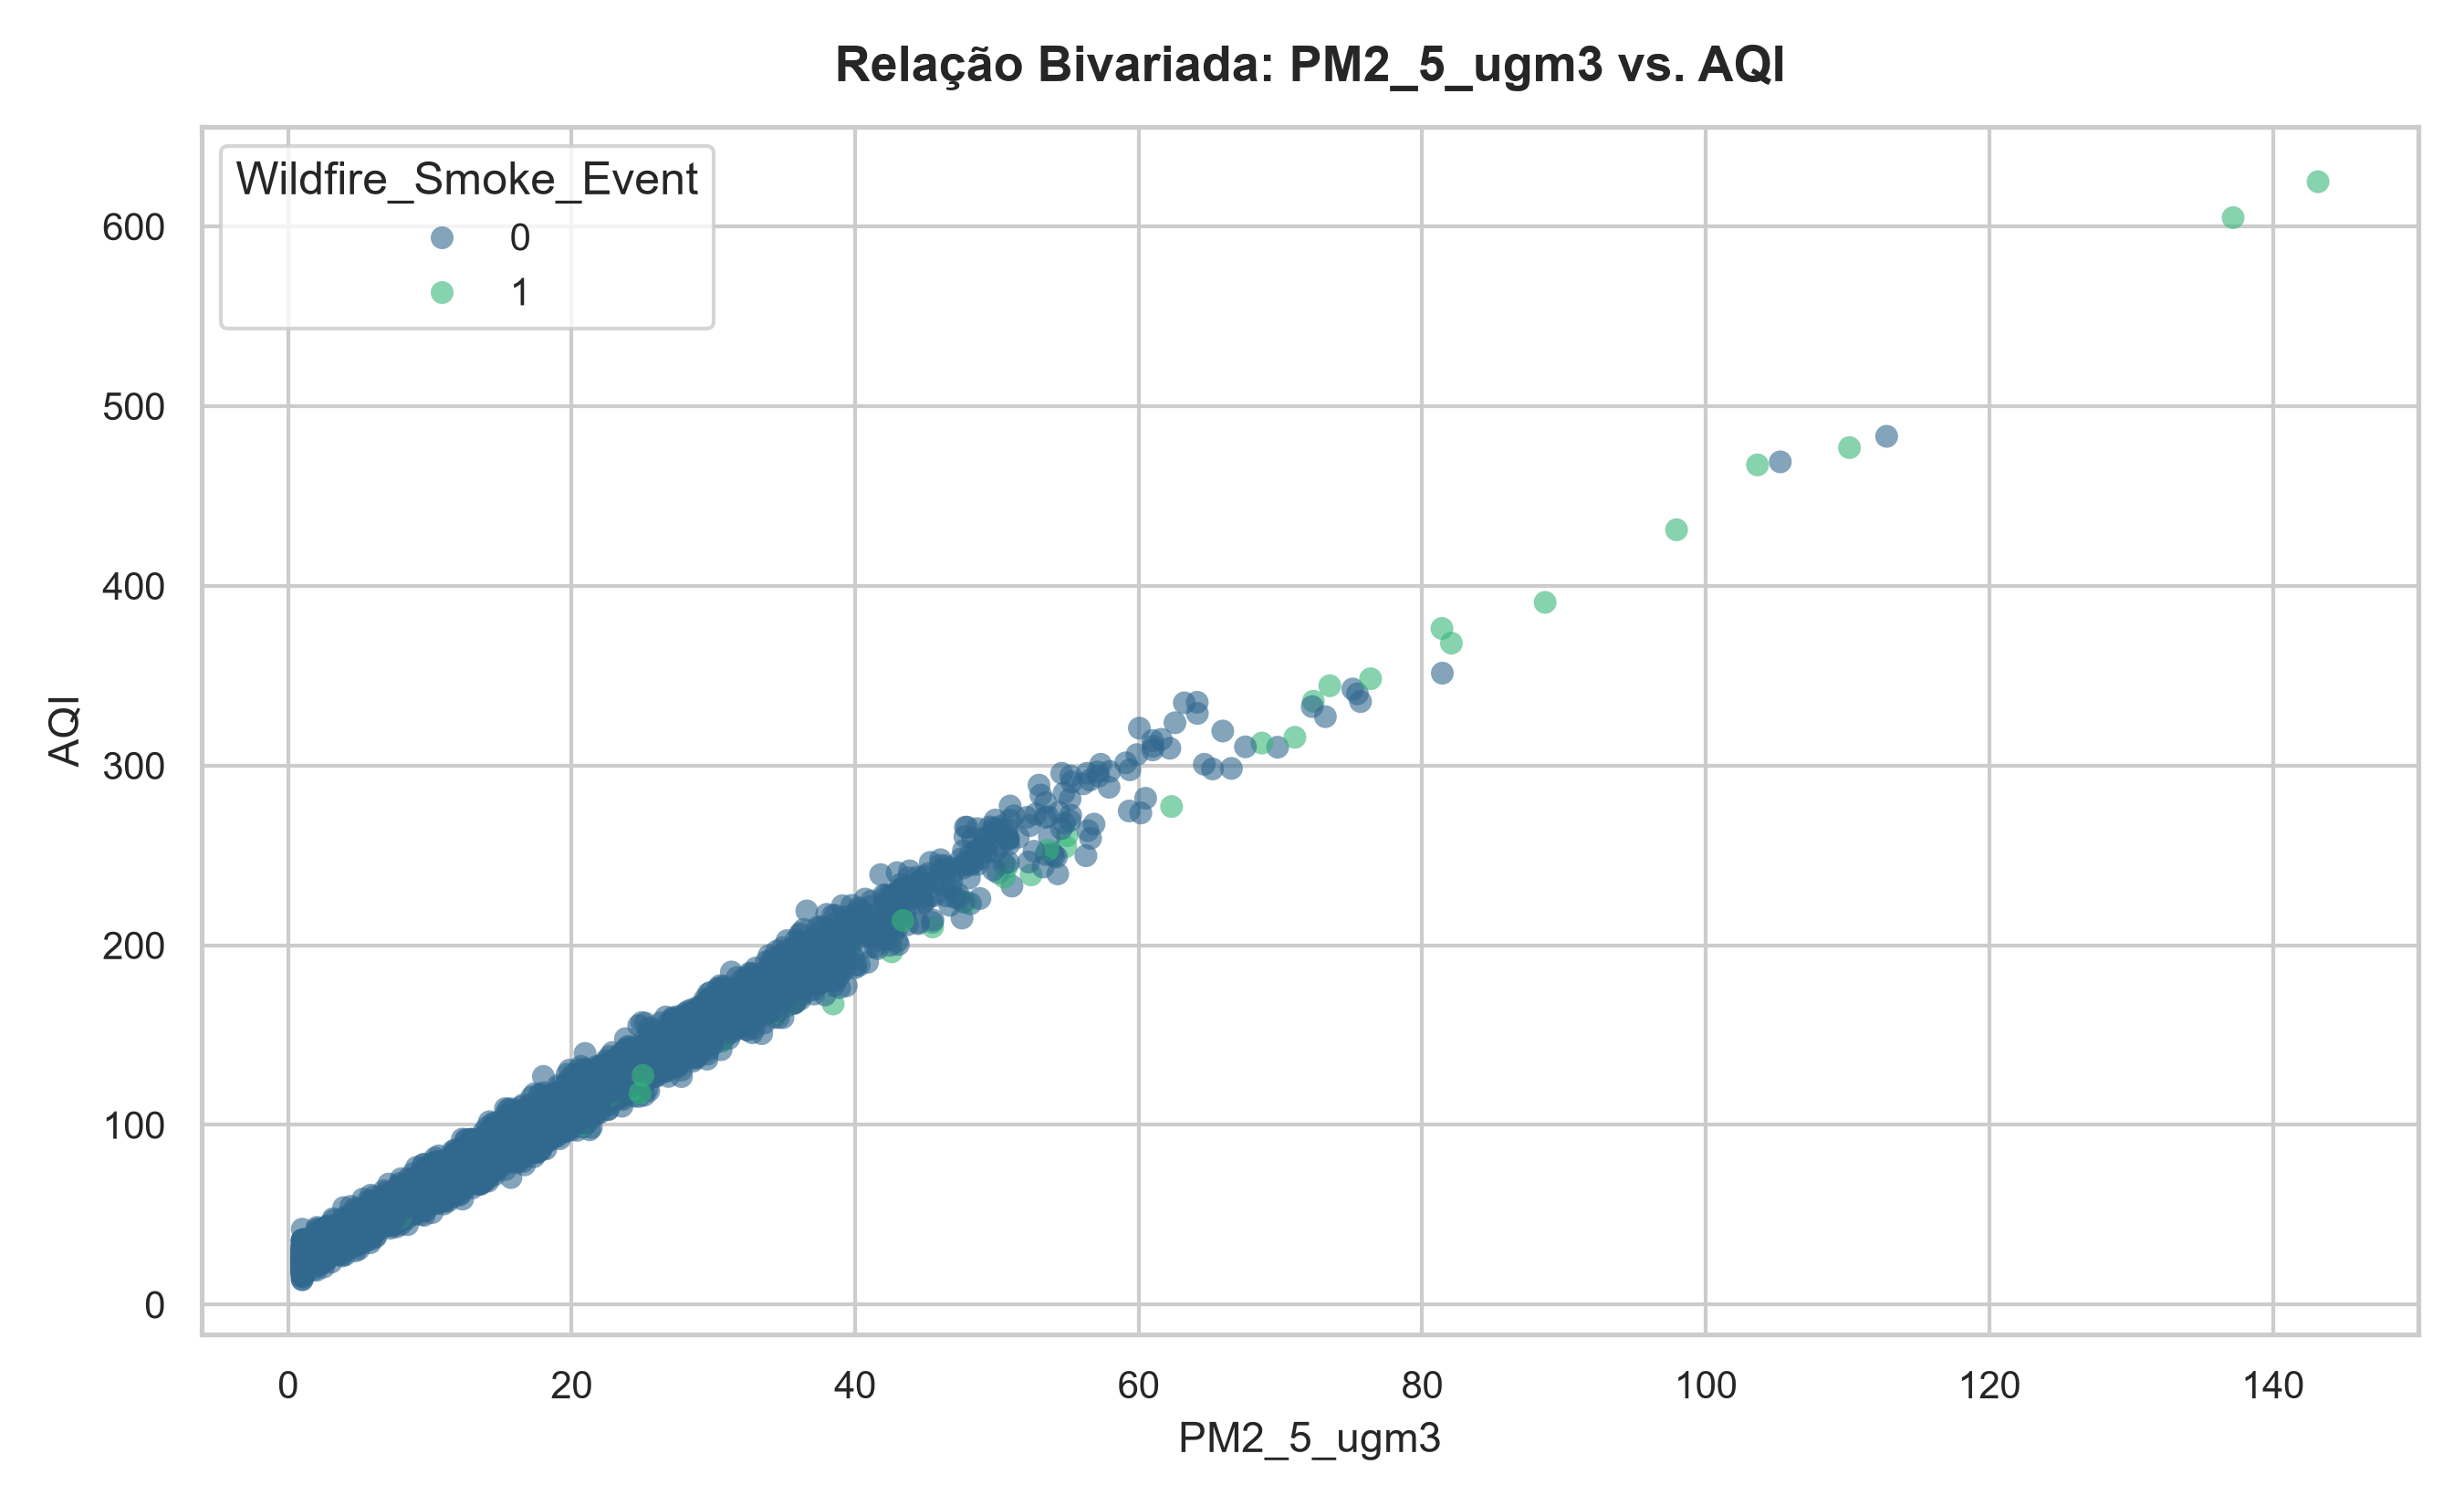

In [13]:
# 2. Relação entre PM2.5 e AQI colorida por Evento de Incêndio Florestal
fig_scatter_pm25 = visualization.plot_scatter(
    df, x_col="PM2_5_ugm3", y_col="AQI", hue="Wildfire_Smoke_Event", save_name="scatter_pm25_aqi.png"
)
Image(filename=str(fig_scatter_pm25))

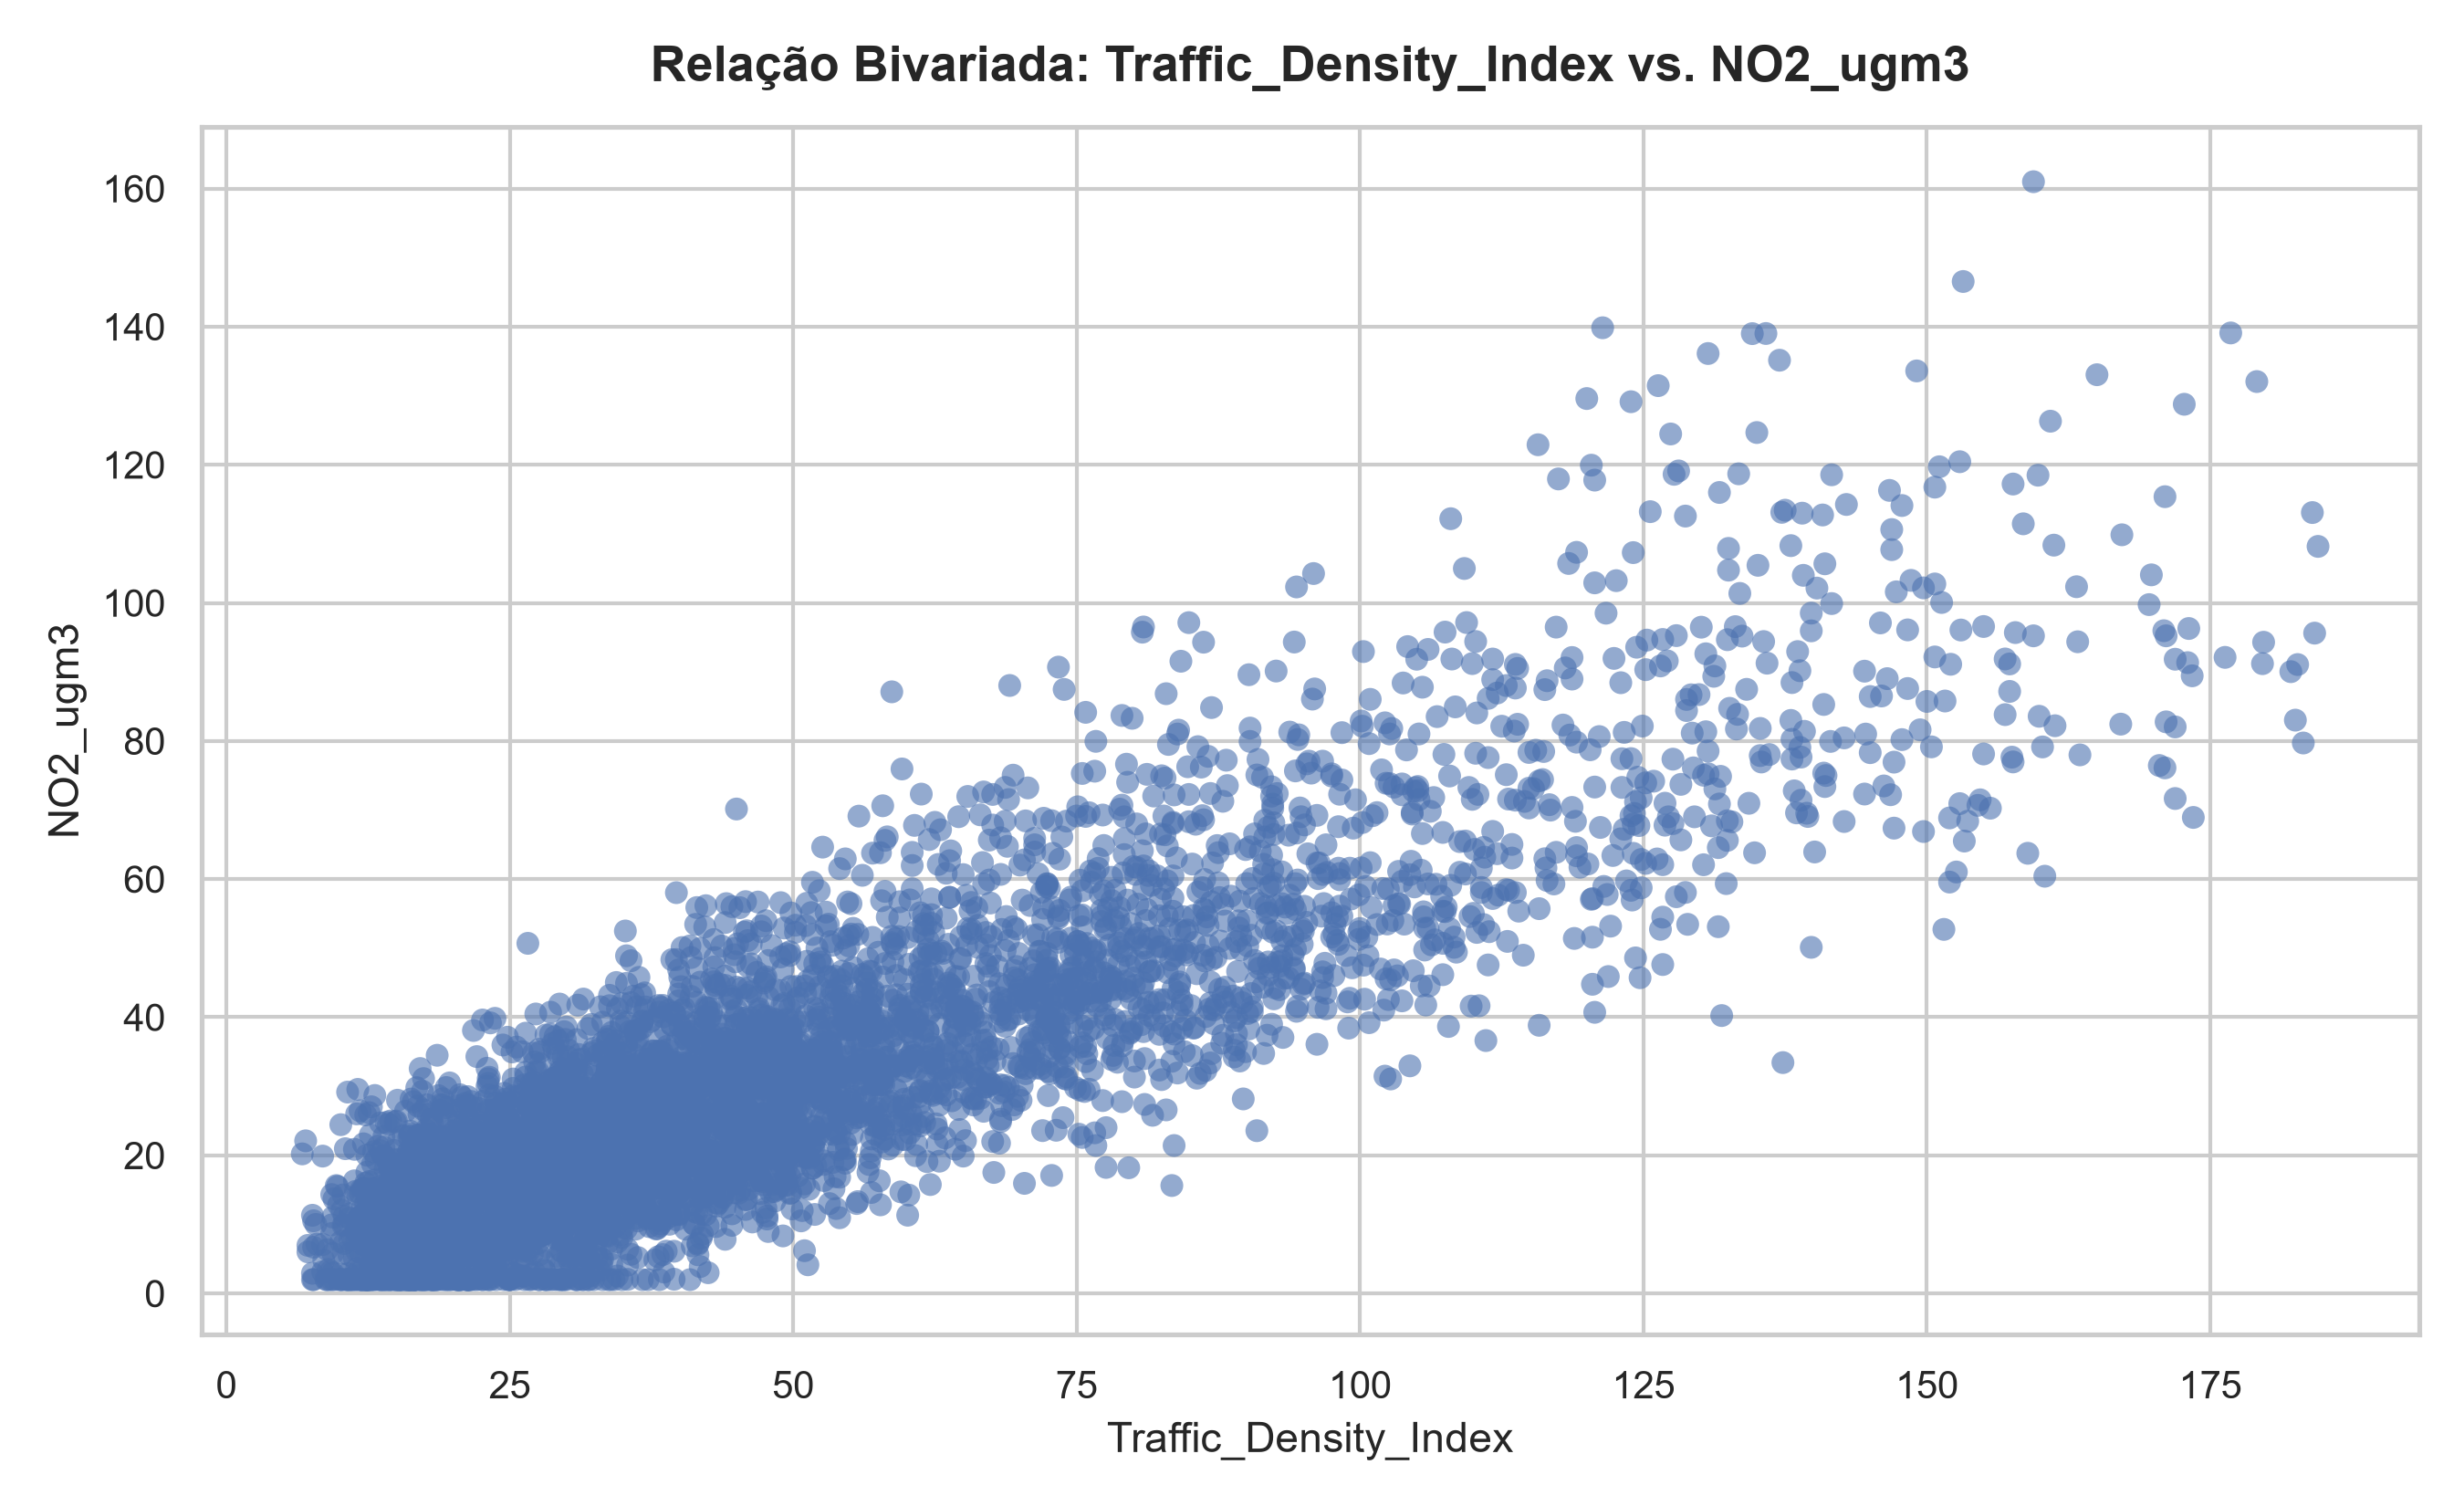

In [14]:
# 3. Relação entre Densidade de Tráfego e NO2
fig_scatter_traffic = visualization.plot_scatter(
    df, x_col="Traffic_Density_Index", y_col="NO2_ugm3", save_name="scatter_traffic_no2.png"
)
Image(filename=str(fig_scatter_traffic))

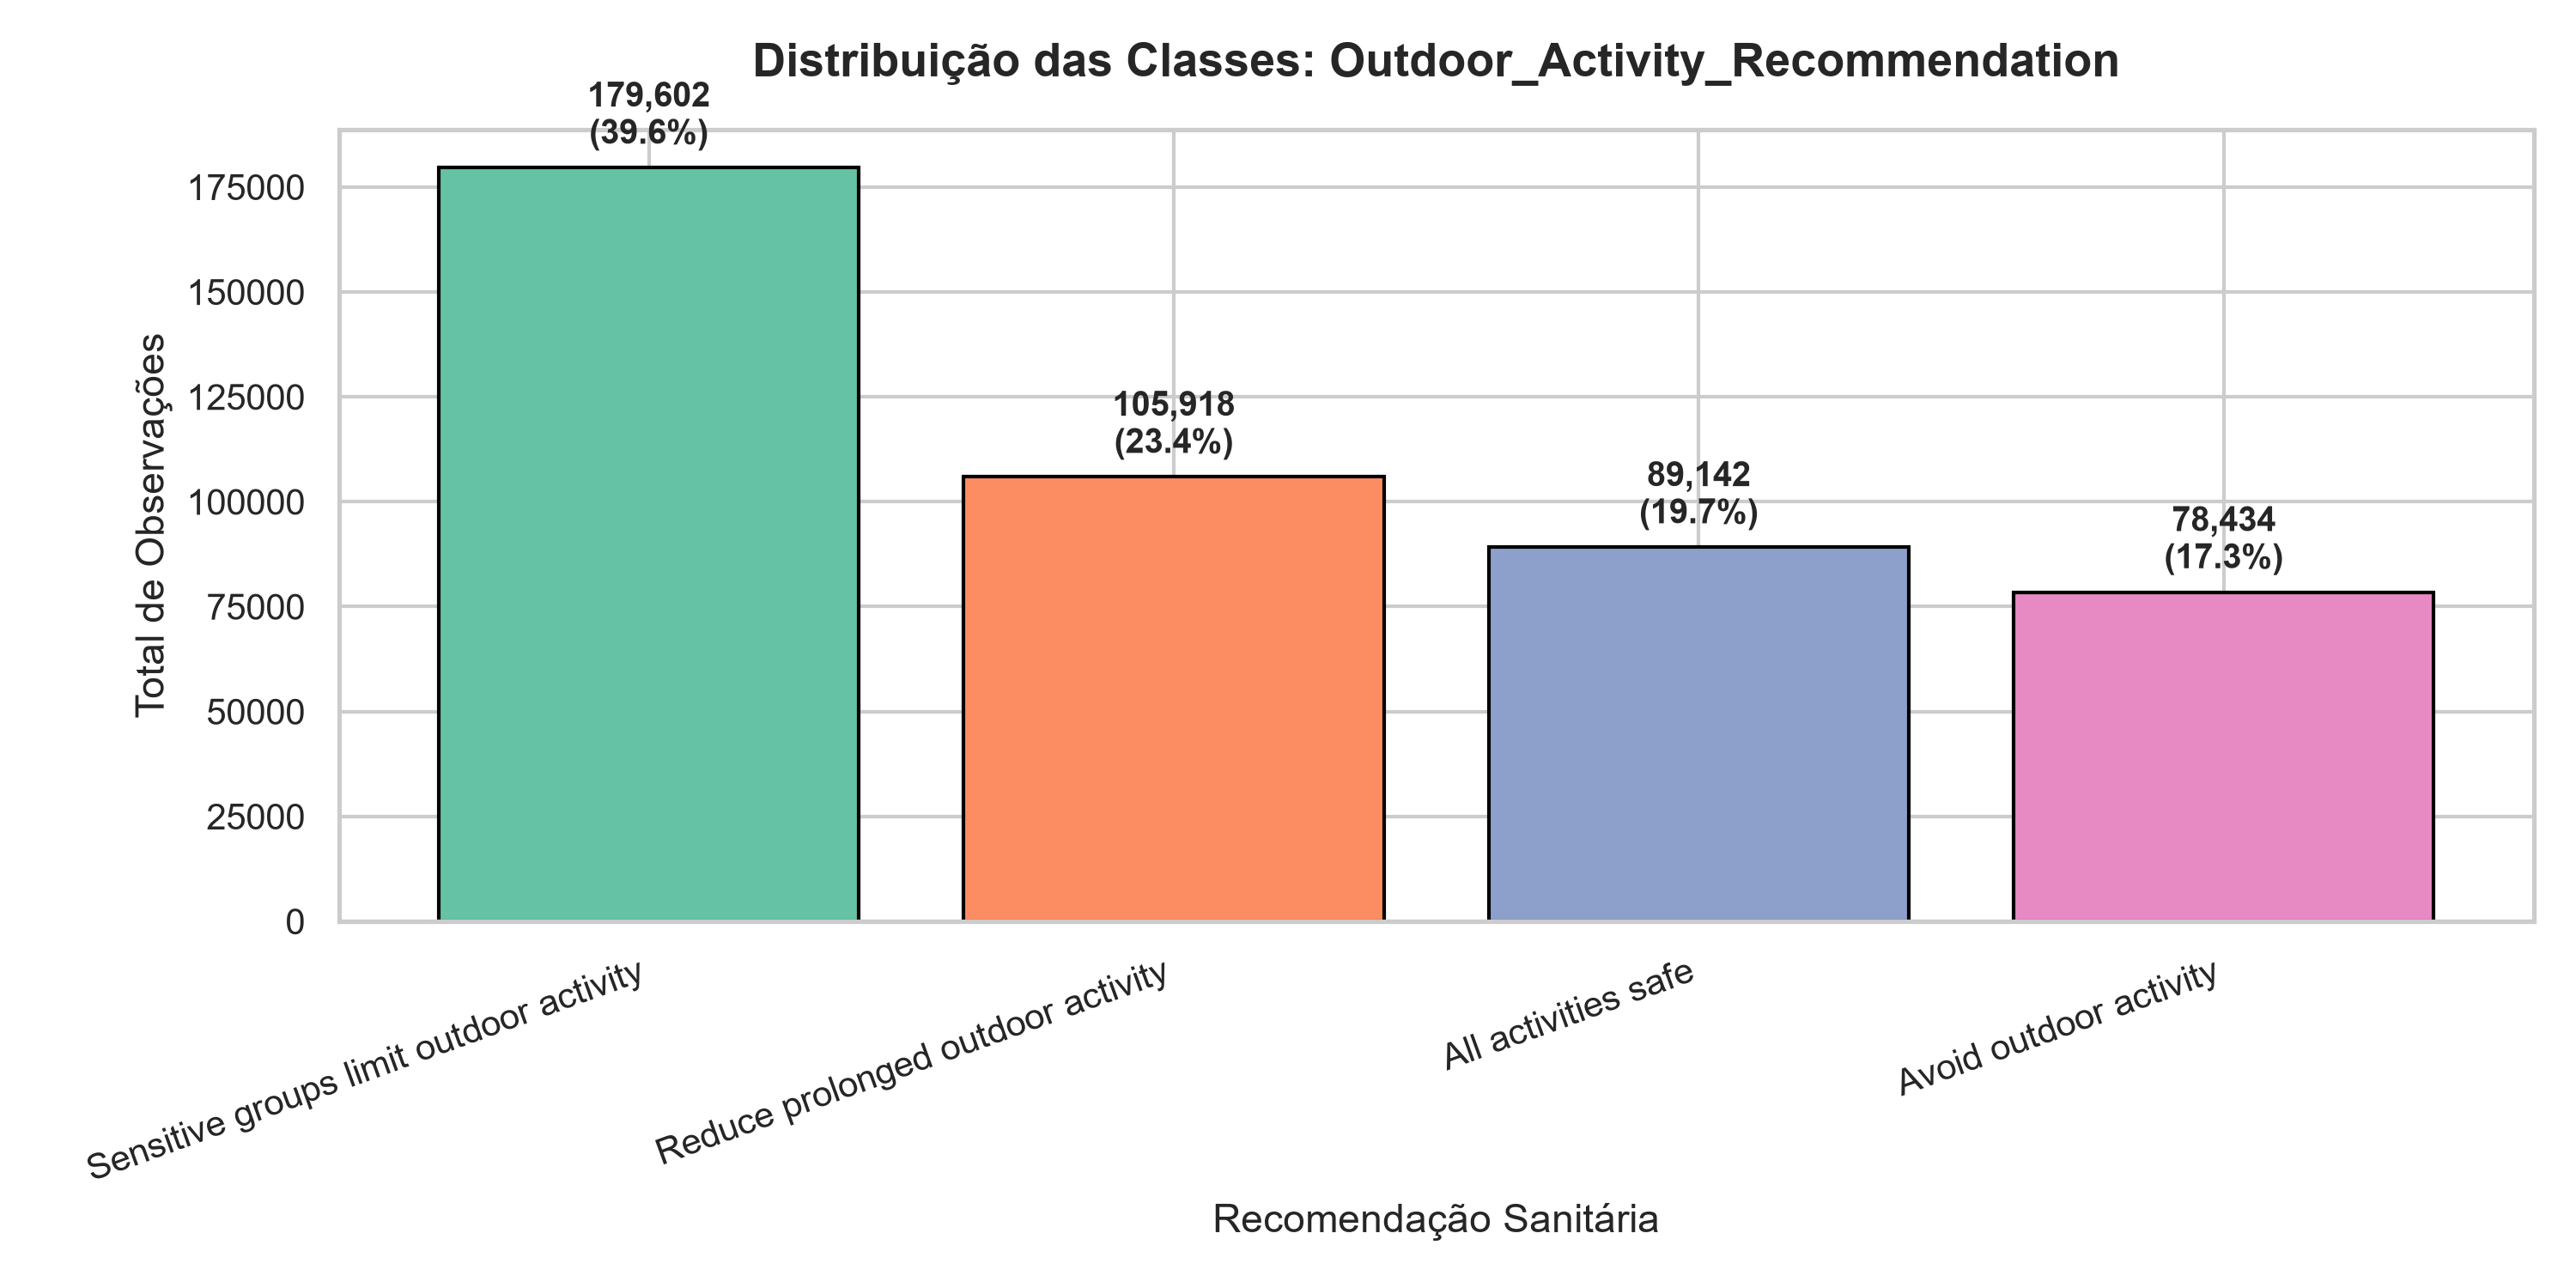

In [15]:
# 4. Distribuição das Classes de Recomendação Sanitária
fig_dist_rec = visualization.plot_class_distribution(
    df, "Outdoor_Activity_Recommendation", "classification_classes_distribution.png"
)
Image(filename=str(fig_dist_rec))

### 7. Síntese e Escolha dos Targets
Com base na análise exploratória completa:
1. **Target de Regressão Escolhido: `AQI` (Air Quality Index)**
   - Variável numérica contínua, com grande amplitude ($12.10$ a $729.10$), sensível a variações climáticas, urbanas e geográficas.
2. **Target de Classificação Escolhido: `Outdoor_Activity_Recommendation`**
   - Variável categórica ordinal de 4 classes bem distribuídas (entre 17.3% e 39.6%), com relevância direta para a saúde pública e tomada de decisão.